# Non-Private Loss Curves Grid

This notebook reads the non-private TT-LoRA sweep CSV and plots train/validation loss over epochs across ranks and core counts.

In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')


In [15]:
CSV_PATH = Path('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/runs/rank2_6_10_nonprivate.csv')
OUTPUT_DIR = Path('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/nonprivate_loss_curves')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
selected_dataset = 'enron'
selected_ranks = [2, 6, 10]
selected_cores = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

CSV_PATH, OUTPUT_DIR


(PosixPath('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/runs/rank2_6_10_nonprivate.csv'),
 PosixPath('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/nonprivate_loss_curves'))

In [16]:
df = pd.read_csv(CSV_PATH)
for column in ['rank', 'core_count', 'epoch', 'train.eval_losses', 'val.eval_losses']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df = df[df['dataset'].astype(str).str.lower() == selected_dataset.lower()].copy()
df = df[df['rank'].isin(selected_ranks)].copy()
df = df[df['core_count'].isin(selected_cores)].copy()

print('shape:', df.shape)
display(df[['run_name', 'rank', 'core_count', 'epoch', 'train.eval_losses', 'val.eval_losses']].head())


shape: (3423, 33)


,run_name,rank,core_count,epoch,train.eval_losses,val.eval_losses
0,ttlora_nonprivate_yes_datasetenron_rank10_eps0...,10,10,0.000000,3.873408,3.755304
1,ttlora_nonprivate_yes_datasetenron_rank10_eps0...,10,10,0.988048,3.254555,3.240966
2,ttlora_nonprivate_yes_datasetenron_rank10_eps0...,10,10,1.988048,3.155589,3.156294
3,ttlora_nonprivate_yes_datasetenron_rank10_eps0...,10,10,2.988048,3.125409,3.132413
4,ttlora_nonprivate_yes_datasetenron_rank10_eps0...,10,10,3.988048,3.096728,3.109393


/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/nonprivate_loss_curves/nonprivate_loss_curves_grid_enron.png


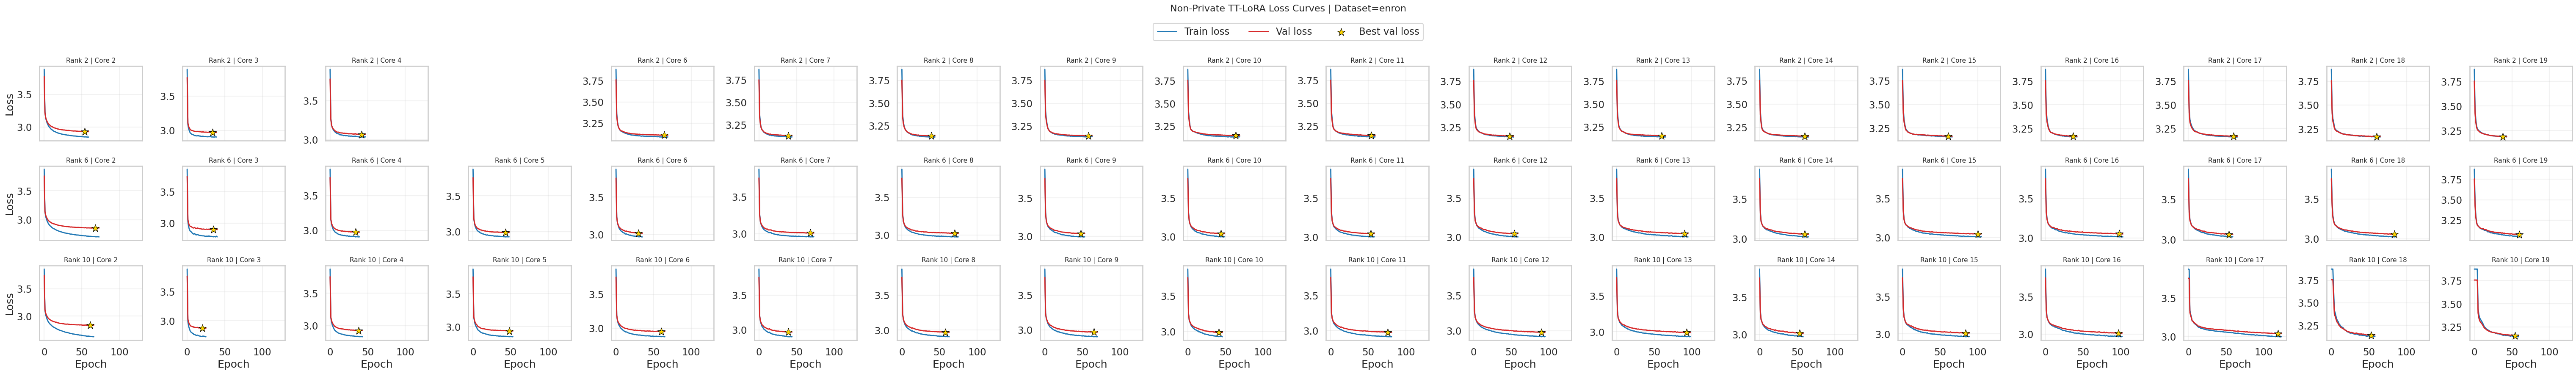

In [17]:
rank_list = sorted(df['rank'].dropna().unique())
core_list = sorted(df['core_count'].dropna().unique())

fig, axes = plt.subplots(
    nrows=len(rank_list),
    ncols=len(core_list),
    figsize=(3.4 * len(core_list), 2.8 * len(rank_list)),
    squeeze=False,
    sharex=True,
    sharey=False,
)

for row_idx, rank in enumerate(rank_list):
    for col_idx, core in enumerate(core_list):
        ax = axes[row_idx][col_idx]
        run_df = df[(df['rank'] == rank) & (df['core_count'] == core)].copy()

        if run_df.empty:
            ax.set_axis_off()
            continue

        run_df = run_df.sort_values('epoch')
        ax.plot(run_df['epoch'], run_df['train.eval_losses'], color='#1f77b4', linewidth=2, label='Train loss')
        ax.plot(run_df['epoch'], run_df['val.eval_losses'], color='#d62728', linewidth=2, label='Val loss')

        best_idx = run_df['val.eval_losses'].idxmin()
        best_row = run_df.loc[best_idx]
        ax.scatter(
            best_row['epoch'],
            best_row['val.eval_losses'],
            marker='*',
            s=180,
            color='gold',
            edgecolor='black',
            linewidth=0.8,
            zorder=5,
            label='Best val loss' if row_idx == 0 and col_idx == 0 else None,
        )

        ax.set_title(f'Rank {int(rank)} | Core {int(core)}', fontsize=11)
        ax.grid(alpha=0.25)

        if row_idx == len(rank_list) - 1:
            ax.set_xlabel('Epoch')
        if col_idx == 0:
            ax.set_ylabel('Loss')

handles, labels = axes[0][0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f'Non-Private TT-LoRA Loss Curves | Dataset={selected_dataset}', y=1.06, fontsize=16)
fig.tight_layout()
loss_grid_path = OUTPUT_DIR / f'nonprivate_loss_curves_grid_{selected_dataset}.png'
fig.savefig(loss_grid_path, dpi=300, bbox_inches='tight')
print(loss_grid_path)
plt.show()


,rank,core_count,best_epoch,epochs_to_converge,best_train_loss,best_val_loss,generalization_gap,num_params
0,2,2,53.988048,53.988048,2.848830,2.928806,0.079976,110592
1,2,3,33.988048,33.988048,2.901825,2.966604,0.064779,59232
2,2,4,41.988048,41.988048,3.034605,3.065783,0.031178,10272
3,2,6,63.988048,63.988048,3.088415,3.109969,0.021554,5568
4,2,7,38.988048,38.988048,3.110332,3.125081,0.014749,5184
5,2,8,38.988048,38.988048,3.125043,3.137541,0.012498,4176
6,2,9,57.988048,57.988048,3.131416,3.143455,0.012039,3792
7,2,10,63.988048,63.988048,3.131515,3.146530,0.015015,3792
8,2,11,53.988048,53.988048,3.129038,3.143431,0.014392,3792
9,2,12,47.988048,47.988048,3.146925,3.156109,0.009184,3792


/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/nonprivate_loss_curves/nonprivate_generalization_convergence_enron.png


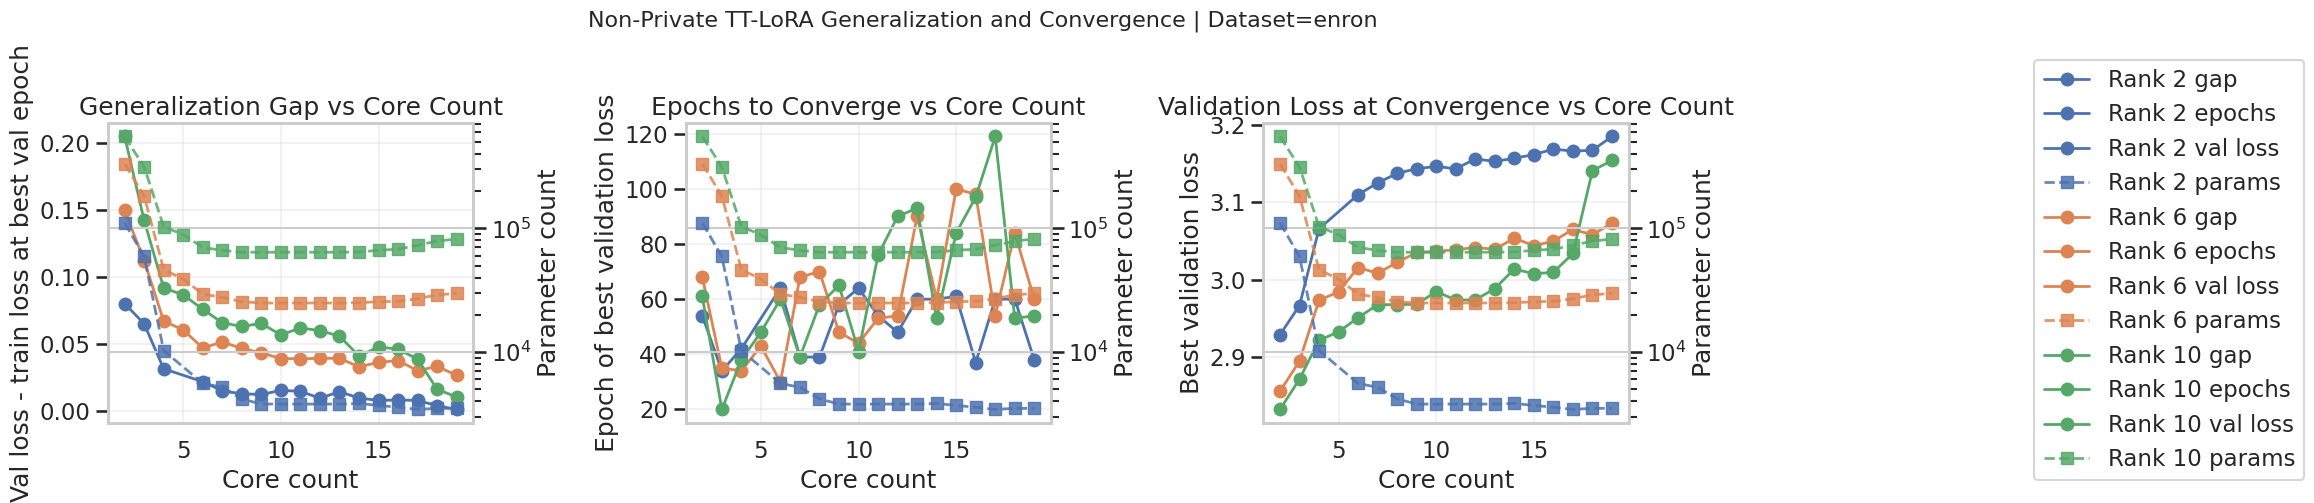

In [18]:
summary_rows = []

for (rank, core), run_df in df.groupby(['rank', 'core_count']):
    run_df = run_df.sort_values('epoch').copy()
    if run_df.empty:
        continue

    best_idx = run_df['val.eval_losses'].idxmin()
    best_row = run_df.loc[best_idx]
    summary_rows.append({
        'rank': rank,
        'core_count': core,
        'best_epoch': best_row['epoch'],
        'epochs_to_converge': best_row['epoch'],
        'best_train_loss': best_row['train.eval_losses'],
        'best_val_loss': best_row['val.eval_losses'],
        'generalization_gap': best_row['val.eval_losses'] - best_row['train.eval_losses'],
        'num_params': pd.to_numeric(best_row['num_params'], errors='coerce'),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['rank', 'core_count'])
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ax0_right = axes[0].twinx()
ax1_right = axes[1].twinx()
ax2_right = axes[2].twinx()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
handles = []
labels = []

for i, (rank, rank_df) in enumerate(summary_df.groupby('rank')):
    rank_df = rank_df.sort_values('core_count')
    color = colors[i % len(colors)]
    line1, = axes[0].plot(rank_df['core_count'], rank_df['generalization_gap'], marker='o', linewidth=2, color=color, label=f'Rank {int(rank)} gap')
    line2, = axes[1].plot(rank_df['core_count'], rank_df['epochs_to_converge'], marker='o', linewidth=2, color=color, label=f'Rank {int(rank)} epochs')
    line3, = axes[2].plot(rank_df['core_count'], rank_df['best_val_loss'], marker='o', linewidth=2, color=color, label=f'Rank {int(rank)} val loss')
    line4, = ax0_right.plot(rank_df['core_count'], rank_df['num_params'], marker='s', linestyle='--', linewidth=2, color=color, alpha=0.85, label=f'Rank {int(rank)} params')
    line5, = ax1_right.plot(rank_df['core_count'], rank_df['num_params'], marker='s', linestyle='--', linewidth=2, color=color, alpha=0.85, label=f'Rank {int(rank)} params')
    line6, = ax2_right.plot(rank_df['core_count'], rank_df['num_params'], marker='s', linestyle='--', linewidth=2, color=color, alpha=0.85, label=f'Rank {int(rank)} params')
    handles.extend([line1, line2, line3, line4])
    labels.extend([f'Rank {int(rank)} gap', f'Rank {int(rank)} epochs', f'Rank {int(rank)} val loss', f'Rank {int(rank)} params'])

axes[0].set_title('Generalization Gap vs Core Count')
axes[0].set_xlabel('Core count')
axes[0].set_ylabel('Val loss - train loss at best val epoch')
axes[0].grid(alpha=0.25)
ax0_right.set_ylabel('Parameter count')
ax0_right.set_yscale('log')

axes[1].set_title('Epochs to Converge vs Core Count')
axes[1].set_xlabel('Core count')
axes[1].set_ylabel('Epoch of best validation loss')
axes[1].grid(alpha=0.25)
ax1_right.set_ylabel('Parameter count')
ax1_right.set_yscale('log')

axes[2].set_title('Validation Loss at Convergence vs Core Count')
axes[2].set_xlabel('Core count')
axes[2].set_ylabel('Best validation loss')
axes[2].grid(alpha=0.25)
ax2_right.set_ylabel('Parameter count')
ax2_right.set_yscale('log')

if handles:
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

fig.suptitle(f'Non-Private TT-LoRA Generalization and Convergence | Dataset={selected_dataset}', y=1.02, fontsize=16)
fig.tight_layout(rect=[0, 0, 0.88, 1])
summary_plot_path = OUTPUT_DIR / f'nonprivate_generalization_convergence_{selected_dataset}.png'
fig.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
print(summary_plot_path)
plt.show()
